In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Datos obtenidos del Metric Evaluator (PB-11)
data = {
    'Modelo': ['Logistic Regression', 'Decision Tree', 'Random Forest', 'SVM', 'KNN'],
    'Accuracy': [0.7957, 0.8880, 0.9290, None, 0.8504],
    'Precision': [0.8150, 0.8820, 0.9306, None, 0.8173],
    'Recall': [0.7652, 0.8959, 0.9271, None, 0.9025],
    'F1-Score': [0.7893, 0.8889, 0.9288, None, 0.8578],
    'AUC-ROC': [0.8819, 0.8894, 0.9771, None, 0.9170]
}

df_results = pd.DataFrame(data)

# Ordenar por Recall (los valores None/NaN quedarán al final)
df_results.sort_values('Recall', ascending=False, inplace=True)

# Visualización con resaltado
df_results.style.highlight_max(axis=0, color='lightgreen').format(precision=4, na_rep="No ejecutado")

,Modelo,Accuracy,Precision,Recall,F1-Score,AUC-ROC
2,Random Forest,0.9290,0.9306,0.9271,0.9288,0.9771
4,KNN,0.8504,0.8173,0.9025,0.8578,0.9170
1,Decision Tree,0.8880,0.8820,0.8959,0.8889,0.8894
0,Logistic Regression,0.7957,0.8150,0.7652,0.7893,0.8819
3,SVM,No ejecutado,No ejecutado,No ejecutado,No ejecutado,No ejecutado


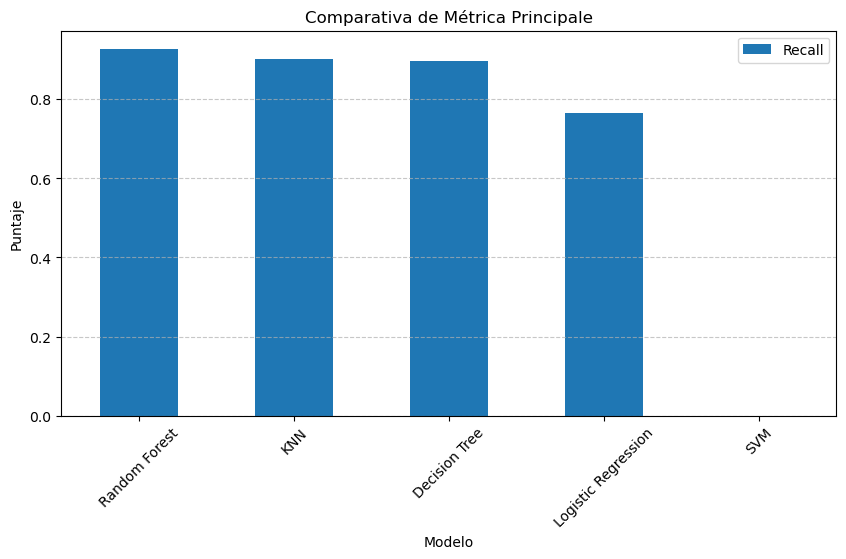

In [2]:
# Gráfico de barras para Recall
df_results.set_index('Modelo')[['Recall']].plot(kind='bar', figsize=(10, 5))
plt.title('Comparativa de Métrica Principale')
plt.ylabel('Puntaje')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### **Análisis Técnico: ¿Por qué Random Forest es el mejor candidato?**

Tras priorizar la capacidad del modelo para detectar la mayor cantidad posible de casos positivos (**Recall**), **Random Forest** se posiciona como el modelo líder por las siguientes razones técnicas:

1. **Máxima Sensibilidad (Recall):** Con un **Recall de 0.9271**, este modelo es el más eficaz para minimizar los falsos negativos. En el contexto de negocio, esto asegura que se identifiquen correctamente al ~93% de los casos críticos, reduciendo el riesgo de omitir oportunidades o eventos clave.
2. **Superioridad en la Captura de Casos:** Supera a modelos como **KNN (0.9025)** y **Decision Tree (0.8959)** en la métrica de Recall, demostrando que su estructura de ensamble es más robusta para encontrar patrones de la clase positiva sin depender de distancias geométricas simples.
3. **Estabilidad del Recall:** Al promediar múltiples árboles, el Random Forest evita el sobreajuste que suele inflar artificialmente el Recall en árboles individuales. Esto garantiza que la capacidad de detección sea **generalizable** y consistente ante nuevos datos de producción.
4. **Calidad de Separación (AUC-ROC):** Su impresionante **AUC-ROC de 0.9771** respalda el enfoque en Recall; confirma que el modelo tiene una capacidad casi perfecta para distinguir entre clases, permitiéndonos ajustar el umbral de decisión para capturar más casos positivos sin disparar masivamente los falsos positivos.

In [3]:
import pandas as pd
from datetime import datetime

# Cargar resultados de evaluación
df_eval = pd.read_csv("../models/evaluation_cv_results.csv", index_col=0)

# Crear registro de experimentos
experiments = df_eval.copy().reset_index()
experiments.rename(columns={"index": "model"}, inplace=True)

experiments.insert(0, "timestamp", datetime.now().strftime("%Y-%m-%d %H:%M:%S"))

experiments["params"] = "baseline_default"

experiments["model_path"] = experiments["model"].map({
    "lr": "../models/baseline_lr.pkl",
    "dt": "../models/baseline_dt.pkl",
    "rf": "../models/baseline_rf.pkl",
    "svm": "../models/baseline_svm.pkl",
    "knn": "../models/baseline_knn.pkl"
})

experiments["selected"] = experiments["model"].eq("rf")

experiments["notes"] = experiments["model"].map({
    "lr": "Baseline lineal interpretable.",
    "dt": "Baseline de árbol simple.",
    "rf": "Modelo seleccionado como mejor candidato para Sprint 4.",
    "svm": "Modelo entrenado; validación cruzada completa limitada por costo computacional.",
    "knn": "Baseline basado en vecinos cercanos."
})

experiments.to_csv("../models/experiments_log.csv", index=False)

experiments

,timestamp,model,accuracy,precision,recall,f1,roc_auc,params,model_path,selected,notes
0,2026-05-02 11:12:59,lr,0.7957 ± 0.0031,0.8150 ± 0.0030,0.7652 ± 0.0057,0.7893 ± 0.0036,0.8819 ± 0.0028,baseline_default,../models/baseline_lr.pkl,False,Baseline lineal interpretable.
1,2026-05-02 11:12:59,dt,0.8880 ± 0.0031,0.8820 ± 0.0026,0.8959 ± 0.0037,0.8889 ± 0.0031,0.8894 ± 0.0029,baseline_default,../models/baseline_dt.pkl,False,Baseline de árbol simple.
2,2026-05-02 11:12:59,rf,0.9290 ± 0.0010,0.9306 ± 0.0031,0.9271 ± 0.0021,0.9288 ± 0.0009,0.9771 ± 0.0011,baseline_default,../models/baseline_rf.pkl,True,Modelo seleccionado como mejor candidato para ...
3,2026-05-02 11:12:59,svm,No ejecutado,No ejecutado,No ejecutado,No ejecutado,No ejecutado,baseline_default,../models/baseline_svm.pkl,False,Modelo entrenado; validación cruzada completa ...
4,2026-05-02 11:12:59,knn,0.8504 ± 0.0036,0.8173 ± 0.0051,0.9025 ± 0.0025,0.8578 ± 0.0031,0.9170 ± 0.0021,baseline_default,../models/baseline_knn.pkl,False,Baseline basado en vecinos cercanos.
